<center>
    
## <font color='maroon'>ASTR 21100</font>
## <font color='maroon'>Computational techniques in astrophysics<br></font>

## <font color='maroon'>Approximation methods for univariate functions</font>

</center>

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np 

# use jupyter "magic" command to tell it to embed plot into the notebook 
import matplotlib.pyplot as plt
%matplotlib inline

from codes.plotting import plot_prettier, plot_line_points, plot_lines_points, plot_color_map
plot_prettier()

### <font color='blue'>Why do we need to approximate functions? </font>

* To have a smooth approximation to a function represented by noisy data (either due to observational or theoretical uncertainties). 

This is common in statistical analyses and Machine Learning (ML). 

<center>

### <font color='blue'>Approximating functions: interpolation vs regression </font>

<p>
<center>
<img width=800 src="https://media.springernature.com/original/springer-static/image/chp%3A10.1007%2F978-3-319-21176-3_6/MediaObjects/331467_1_En_6_Fig1_HTML.gif"></img>
 

### <font color='blue'>Why do we need to approximate functions with regression? </font>

### <font color='blue'>A frequent application: detrending of regression.</font>


<img width=1000 src="https://github.com/dwkim78/pdtrend/blob/master/pdtrend/datasets/images/PDT_logo.png?raw=true"></img>



### <font color='blue'>Why do we need to approximate functions? </font>


* To be able to compute function values between available tabulated (training) points. 

* To get continuous approximation for the derivatives. 

* To speed up calculation. 

***Example*** below involves a more complicated function. This function is computed with <a href="https://camb.info/">the CAMB code</a> computing evolution of small perturbations in the early stages of the universe by solving a system of Boltzmann differential equations. 

### <font color='blue'>Any function $f(x)$ can be approximated by</font>

$$f(x)\approx \sum\limits_{k=0}^m a_k\psi_k(x),$$


where $a_k$ are constant coefficients and $\psi_k$ is a basis set of linearly independent functions. For example, global polynomial approximation $\psi_k=x^k$. 

### <font color='blue'>Joseph Fourier (1768-1830)</font>
<p>
<center>
<img width=500 src="https://upload.wikimedia.org/wikipedia/commons/0/0a/Fourier_in_his_coat_of_prefect.jpg"></img>


Fourier first presented a paper to the French Academy of Sciences in 1807, arguing that the above is true for $\psi_k$ that are constructed out of sines and cosines (trigonometric functions). Such approximation has become known as the Fourier transform, but back in 1807 most mathematician did not believe him.  

### <font color='blue'>Let's try to test this in practice</font>

In [2]:
class Basis_Approx():
    def __init__(self, xtrain, ftrain, wtrain=None, m=None, psi='gaussian', **kwargs):
        """
        initialize class for basis function expansion
        
        Parameters:
            xtrain, ftrain: 1d arrays with training x and function values
            wtrain: optional 1d array with weights for each training point
            m: int, the number of terms in the expansion is m+1
            psi: choice of psi_k function: top-hat constant within abs(x-x_k)<eps, 
              linear = abs(x-x_k)
        """
        funcs = {'const': self.const, 'linear': self.linear, 'cubic': self.cubic, 
                 'monomial': self.monomial, 'cubic_spline': self.cubic_spline, 
                 'thin_plate': self.thin_plate, 'gaussian': self.gaussian}
        self.func = funcs[psi]
        self.xtrain = xtrain
        self.ftrain = ftrain
        self.kwargs = kwargs
        self.wtrain = wtrain
        if m is None:
            self.m = len(xtrain)
        else:
            assert(m+1 <= len(xtrain))
            self.m = m + 1
            
        # solve for the expansion coefficients
        if self.wtrain is None: 
            self.phi_mat = self.kernel_matrix(xtrain)
            self.coeffs = self.compute_coeffs(self.phi_mat, ftrain)
        else:
            self.phi_mat, ftrainw = self.kernel_wmatrix(xtrain)
            self.coeffs = self.compute_coeffs(self.phi_mat, ftrainw)
        
    def monomial(self, x, j=0):
        """Polynomial psi_j = x**j"""
        return x**j

    def gaussian(self, x, j=0, eps=1):
        """
        psi_j(x) = Gaussian with the mean x_j and sigma=eps
        """
        f = np.exp(-0.5 * (x - self.xtrain[j])**2 / eps**2)
        return f
    
    def const(self, x, j=0, eps=1.):
        """
        Tophat basis: 
            psi_j = 1 if abs(x-x_j) < eps,
                    0 otherwise
                    
        """
        if np.isscalar(x):
            if abs(x - self.xtrain[j]) < 0.5*eps:
                return 1.0
            else:
                return 0.0
        else:
            isel = abs(x - self.xtrain[j]) < 0.5*eps
            xt = np.zeros_like(x)
            xt[isel] = 1.0 # 
            return xt
    
    def linear(self, x, j=0):
        return np.abs(x - self.xtrain[j])
    
    def cubic(self, x, j=0):
        return np.abs(x - self.xtrain[j])**3
    
    def cubic_spline(self, x, j=0, eps=1.):
        xn = (x - self.xtrain[j]) / (0.5*eps) 
        if np.isscalar(xn):
            if -2 <= xn < 2:
                if -1 <= xn < 1:
                    return 4 - 6*xn**2 + 3*abs(xn)**3
                else:
                    return (2 - abs(xn))**3
            else:
                return 0.
        else: 
            isel1 = ((xn >= -2) & (xn < -1)) | ((1 <= xn) & (xn < 2))
            isel2 = (xn >= -1) & (xn < 1)
            f = np.zeros_like(xn)
            f[isel2] = 4 - 6*xn[isel2]**2 + 3*abs(xn[isel2])**3
            f[isel1] = (2 - abs(xn[isel1]))**3
            return f 

    def thin_plate(self, x, j=0):
        dx = np.maximum(np.abs(x - self.xtrain[j]), 1e-10)
        return dx**2 * np.log(dx)
                           
    def kernel_matrix(self, xtrain):
        """
        Fill out and return matrix Psi 
        to be used to solve for the coefficients
        """
        nx = len(xtrain)
        phi_mat = np.zeros([nx, self.m])
            
        for i in range(nx):
            for j in range(self.m):
                phi_mat[i, j] = self.func(xtrain[i], j=j, **self.kwargs)
        return phi_mat

    def kernel_wmatrix(self, xtrain):
        """
        Fill out matrices for weighted interpolation or 
        regression
        """
        nx = len(xtrain)
        phi_mat = np.zeros([nx, self.m])
        if self.wtrain is not None: 
            wmat = np.eye(nx)
            np.fill_diagonal(wmat, self.wtrain)
                        
        for i in range(nx):
            for j in range(self.m):
                phi_mat[i, j] = self.func(xtrain[i], j=j, **self.kwargs)
                
        ftrainw = np.dot(phi_mat.T,np.dot(wmat, ftrain))
        phi_matw = np.dot(phi_mat.T,np.dot(wmat, phi_mat))
        return phi_matw, ftrainw

    def compute_coeffs(self, phi_mat, ftrain):
        # solve linear system of equations using SVD
        coeffs = np.linalg.lstsq(phi_mat, ftrain, rcond=None)[0]
        return coeffs
    
    def predict(self, xtest=None):
        """
        Compute and return approximation
        for the input value or array xtest
        """
        if xtest is None:
            raise ValueError('predict requires at least 1 input xtest!')
        fapprox = np.zeros(len(xtest))
        for i in range(len(self.coeffs)):
            fapprox = fapprox + self.coeffs[i] * self.func(xtest, j=i, **self.kwargs)
        return fapprox
    
    def plot_components(self, xtest, fxtest=None, 
                        psize=30, pcol='m', xlims=None, ylims=None, 
                        legend=False, legend_loc=None, 
                        figsave=None, plot_error=False,  
                        plot_approx=True, plot_components=True,
                        figsize=(3,3), xlabel='$x$', ylabel='$f(x)$', ax=None):
        """
        Plot the function and approximation, as well as its 
        individual terms, if needed
        """
        fapprox = self.predict(xtest=xtest)
        if ax is None: 
            fig, ax = plt.subplots(1, 1, figsize=figsize)
            
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if xlims is not None: ax.set_xlim(xlims)
        if ylims is not None: ax.set_ylim(ylims)
        if self.wtrain is not None and plot_error:
            ax.errorbar(self.xtrain, self.ftrain, yerr=1/self.wtrain**2, 
                        fmt='none', ecolor=pcol)
        ax.scatter(self.xtrain, self.ftrain, s=psize, c=pcol)
        
        if plot_components:
            for i, ak in enumerate(self.coeffs):
                if ak != 0.: 
                    psik = self.func(xtest, j=i, **self.kwargs)
                    if np.isscalar(psik): 
                        psik = psik * np.ones_like(xtest)
                    c = ak * psik
                    #print(xtest.size, c.size, c)
                    if i == 0:
                        ax.plot(xtest, c, lw=0.75, ls='dotted', label=r'components')
                    else:
                        ax.plot(xtest, c, lw=0.75, ls='dotted')
        if plot_approx:
            ax.plot(xtest, fapprox, c='darkslateblue', lw=1.5,
                    label=r'approximation')
        if fxtest is not None:
            ax.plot(xtest, fxtest, lw=1.0, ls='--', 
                    c='orangered', label=r'function')
        if legend:
            if legend_loc is None: 
                ax.legend(loc='best', frameon=False, fontsize=9)
            else:
                ax.legend(loc=legend_loc, frameon=False, fontsize=9)
        if figsave is not None: 
            plt.savefig(figsave, bbox_inches='tight')
        if ax is None: plt.show()
        
    


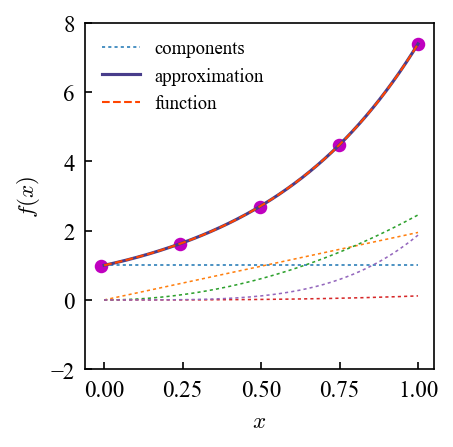

In [3]:
ntrain = 5
xtrain = np.linspace(-0.01, 1., ntrain)
ftrain = np.exp(2*xtrain) # approximate exp(2*x)
ntest = 1000
xtest = np.linspace(0, 1, ntest)
ftest = np.exp(2*xtest) 

bexp = Basis_Approx(xtrain, ftrain, psi='monomial')#, **{'eps': 0.05})

bexp.plot_components(xtest, fxtest=ftest, ylims=[-2,8], legend=True)

### <font color='blue'>Approximating functions: choice of proper basis</font> 


In [4]:
def triangle_scalar(x, eps=1.):
    """
    square pulse (aka top-hat) function centered on of width 1.0 
    
    Parameters: 
    x: scalar value
    """
    if x < -0.5*eps or x > eps*0.5:
        return 0
    elif (x >= -0.5*eps) & (x < 0.5*eps):
        return 1 + x / (0.5*eps)

In [5]:
def triangle(x, eps=1.):
    """
    square pulse (aka top-hat) function centered on of width 1.0 
    
    Parameters: 
    x: scalar value
    """
    t = np.zeros_like(x)
    isel1 = (x >= -0.5*eps) & (x < 0)
    isel2 = (x >= 0) & (x < 0.5*eps)
    t[isel1] = 1 + x[isel1] / (0.5*eps)
    t[isel2] = 1 - x[isel2] / (0.5*eps)
    
    return t

In [6]:
xmin, xmax, ntr = -2, 2, 31
xtr = np.linspace(xmin, xmax, ntr)
ftr = triangle(xtr)

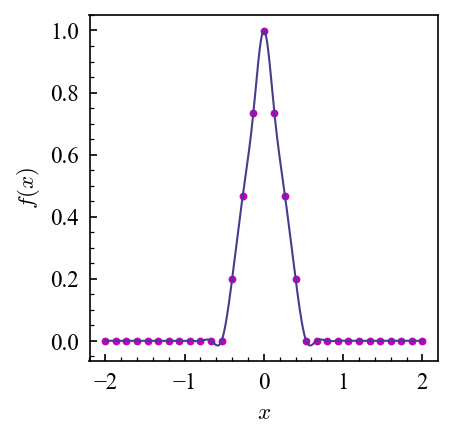

In [9]:
from scipy.interpolate import UnivariateSpline

xt = np.linspace(xmin, xmax, 5000)
spl = UnivariateSpline(xtr, ftr, s=0.)

plot_lines_points(xp=xtr, yp=ftr, x=xt, y=spl(xt), 
                  psize=30, pcol='m', xlabel='$x$', ylabel='$f(x)$', figsize=3)

<IPython.core.display.Javascript object>


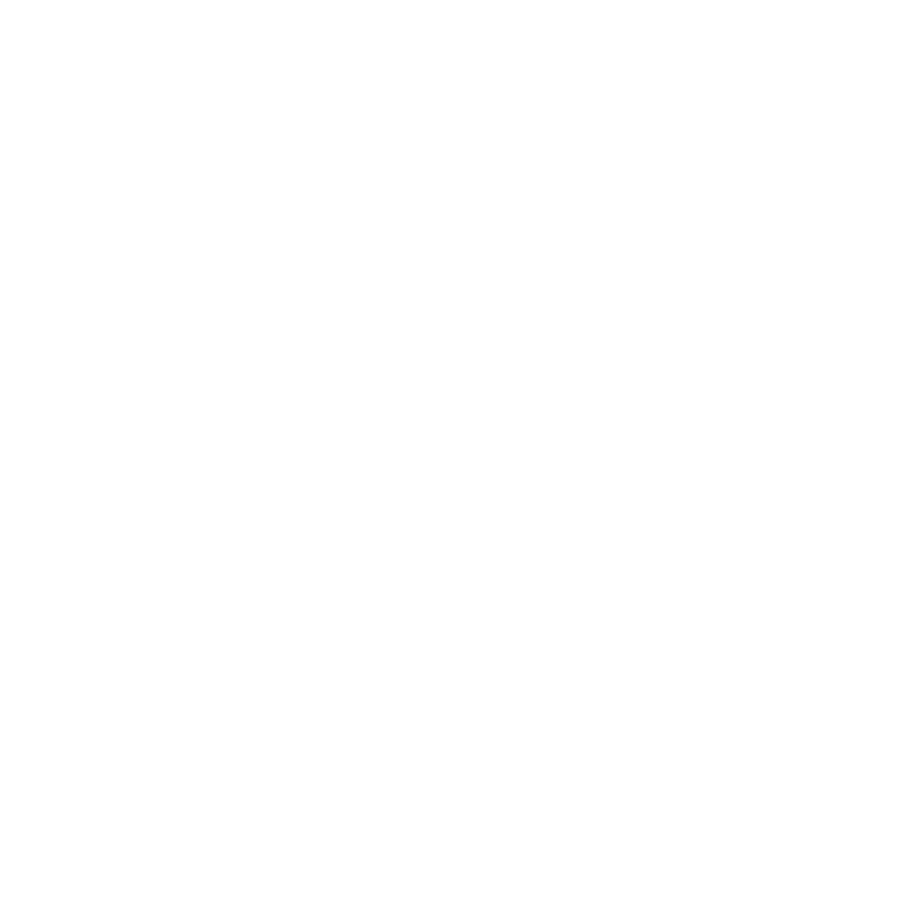

In [10]:
%matplotlib notebook

kwargs = {'eps': (xmax-xmin)/(ntr-1)}
kwargs = {}
bexp = Basis_Approx(xtr, ftr, psi='gaussian', **kwargs)
ftest = bexp.predict(xtest)

bexp.plot_components(xt, fxtest=triangle(xt), ylims=[-0.5, 1.5], legend=True)


### <font color='blue'>Approximating functions with discontinuities</font> 

The functions that have discontinuities present another challenge to smooth interpolators due to the effect called ***Gibbs phenomenon***. 

In [11]:
def square_pulse_scalar(x, eps=1.):
    """
    square pulse (aka top-hat) function centered on of width 1.0 
    
    Parameters: 
    x: scalar value
    """
    if x < -0.5*eps or x > eps*0.5:
        return 0
    elif (x >= -0.5*eps) & (x < 0.5*eps):
        return 1.

In [12]:
def square_pulse(x, eps=1., location=0., amplitude=1.):
    """
    the same as above but vectorized, so that function can take x as numpy vector 
    and return vector of evalued function values
    
    Parameters:
        x: numpy vector of floats
        location: center x of the pulse
        width: width of the pulse
        amplitude: amplitude of the pulse
    """
    fsx = np.zeros_like(x)
    fsx[np.abs(x-location) <= 0.5*eps] = amplitude
    return fsx 

<IPython.core.display.Javascript object>


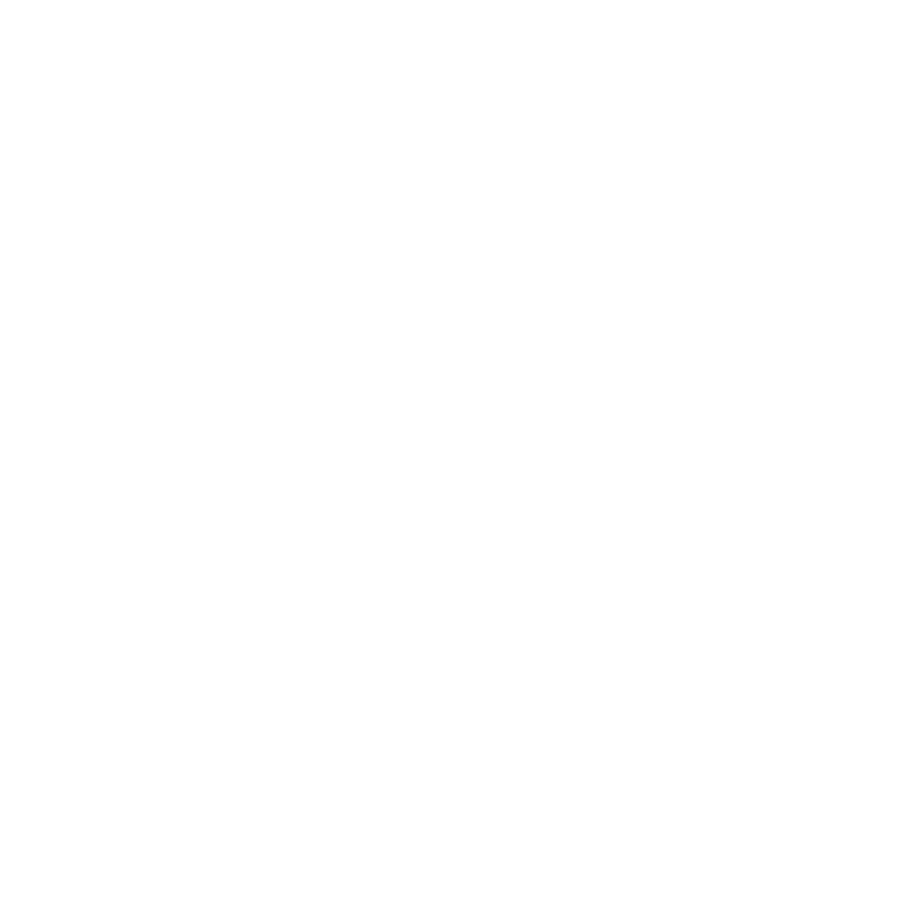

In [13]:
xmin, xmax, ntr = -2, 2, 20
xtr = np.linspace(xmin, xmax, ntr)
ftr = square_pulse(xtr)
xt = np.linspace(xmin, xmax, 5000)

kwargs =  {} # {'eps': (xmax-xmin)/(ntr-1)}

bexp = Basis_Approx(xtr, ftr, psi='thin_plate')
ftest = bexp.predict(xtest)

bexp.plot_components(xt, ylims=[-0.5, 1.5], legend=True)


In [14]:
def square_pulses(x, amps=[2.,1.,3], centers=[-1.5, 0.2, 1.2], widths=[0.2, 0.5, 0.3]):
    fx = np.zeros_like(x)
    for a, c, w in zip(amps, centers, widths):
        fx += square_pulse(x, location=c, eps=w, amplitude=a)        
    return fx

<IPython.core.display.Javascript object>


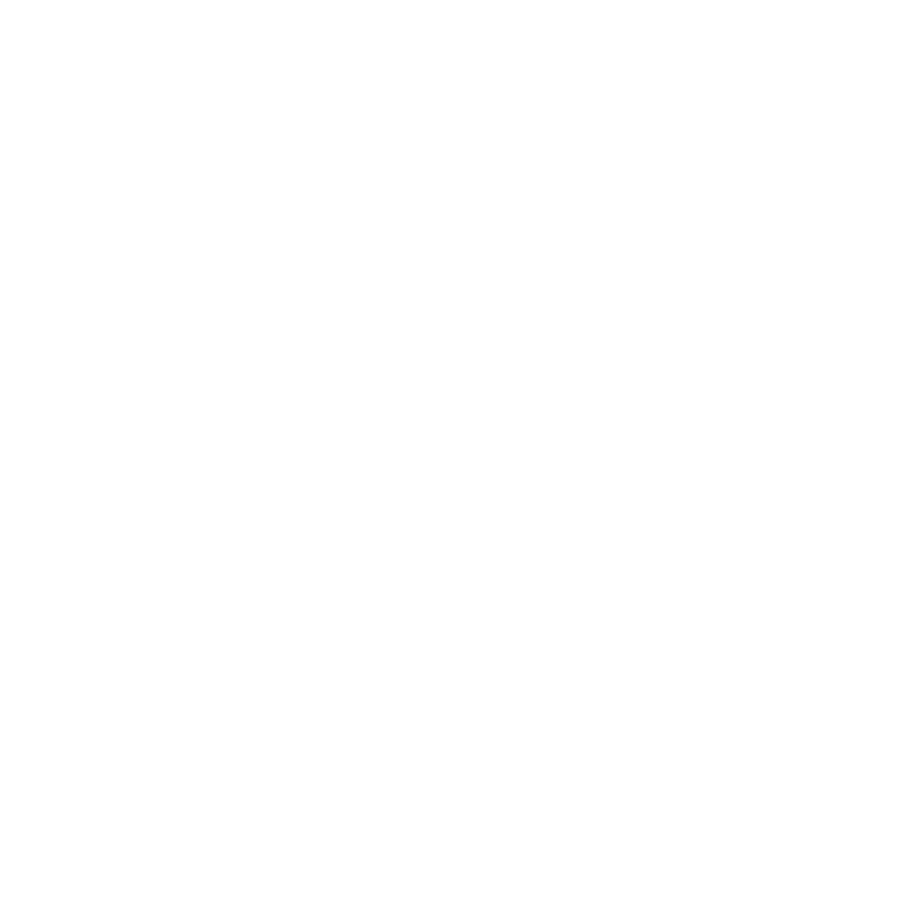

In [15]:
ntr = 30
xmin, xmax = -2, 2.
xtr = np.linspace(xmin, xmax, ntr)
ftr = square_pulses(xtr)

xt = np.linspace(xmin, xmax, 5000)
plot_lines_points(xp=xtr, yp=ftr, x=xt, y=square_pulses(xt), 
                  plot_title = r'tophat basis, %d evenly spaced nodes on interval [%.1f,%.1f]'%(ntr,xmin,xmax),
                  psize=30, pcol='m', xlabel='$x$', ylabel='$f(x)$', figsize=3)

<IPython.core.display.Javascript object>


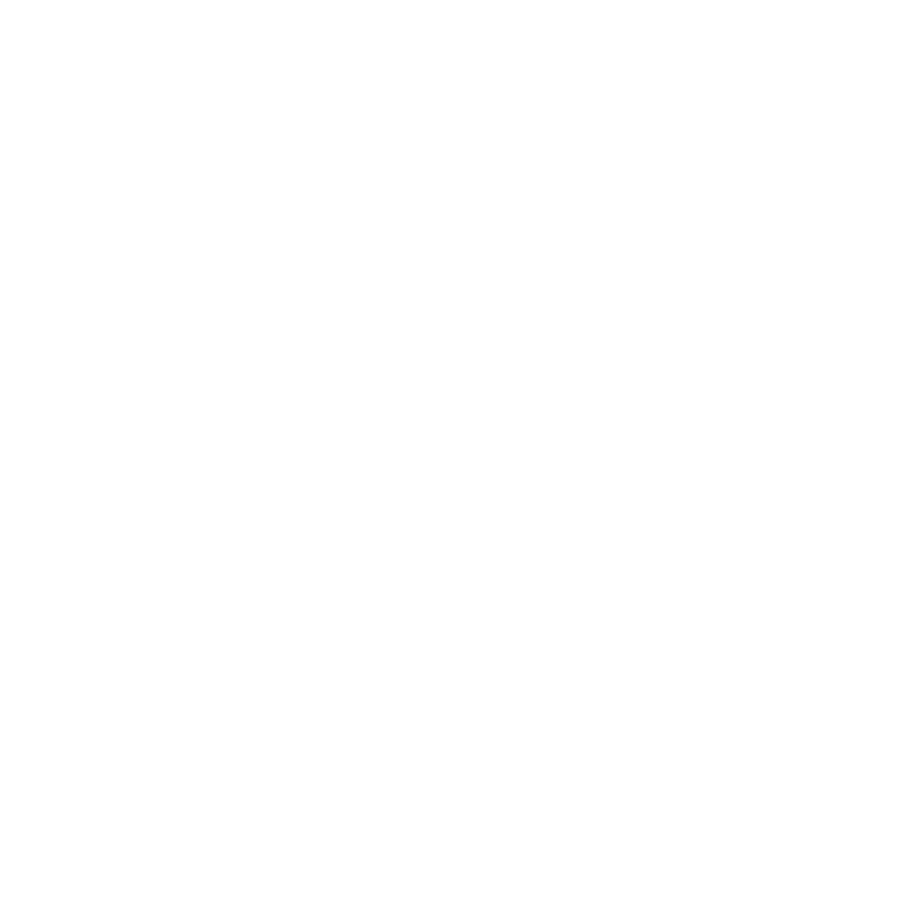

In [16]:
bexp = Basis_Approx(xtr, ftr, psi='const', **{'eps':(xmax-xmin)/(ntr-1)})
ftest = bexp.predict(xtest)

bexp.plot_components(xt, ylims=[-0.5, 3.5])


### <font color='blue'>Approximating smooth functions</font>

<IPython.core.display.Javascript object>


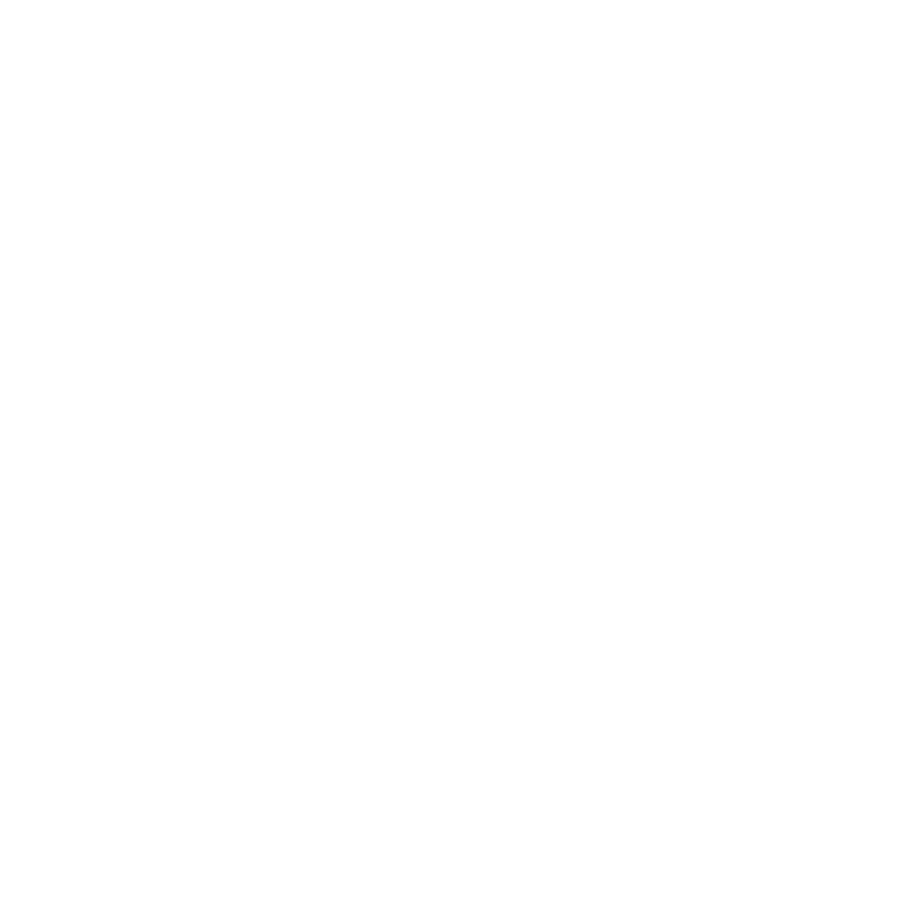

In [17]:
ntrain = 5
xtrain = np.linspace(-0.01, 1., ntrain)
ftrain = np.exp(2*xtrain)
ntest = 1000
xtest = np.linspace(0, 1, ntest)
ftest = np.exp(2*xtest) 

bexp = Basis_Approx(xtrain, ftrain, psi='monomial')


bexp.plot_components(xtest, fxtest=ftest, ylims=[-2,8], legend=True)

### <font color='blue'>Approximating the Runge function</font>

<IPython.core.display.Javascript object>


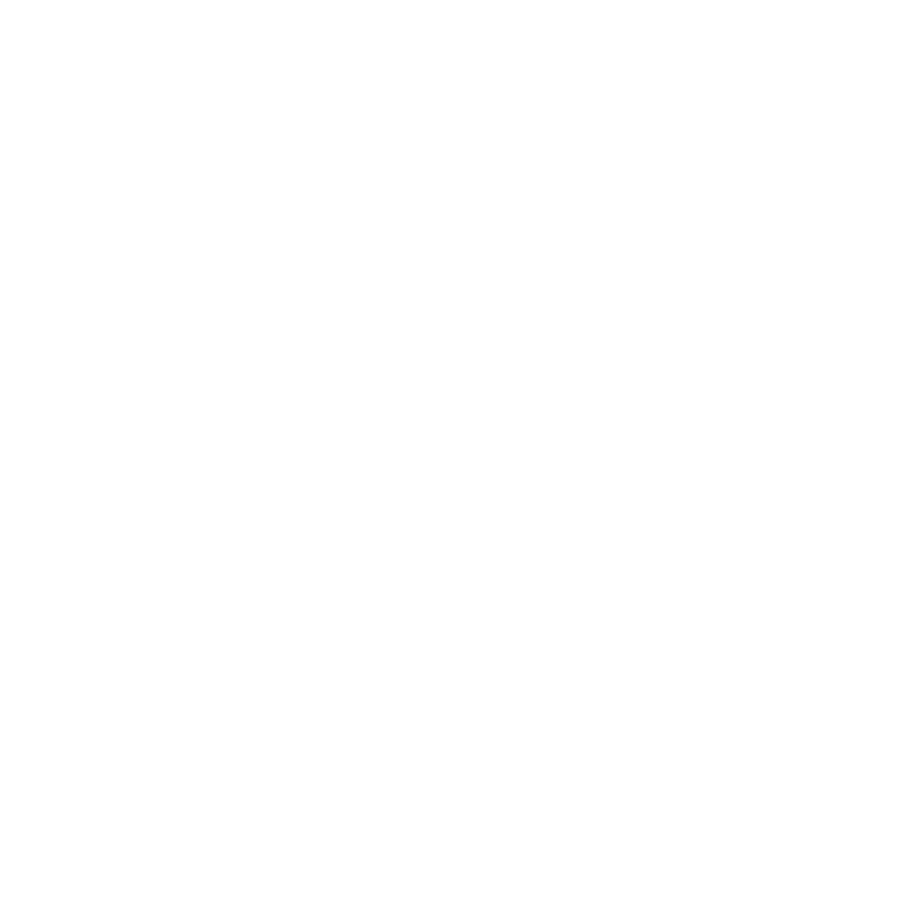

In [18]:
def runge(x):
    return 1. / (1. + x**2)

xtest = np.linspace(-5., 5., 333)
plot_line_points(xtest, runge(xtest), xlabel=r'$x$', ylabel=r'$f(x)$', figsize=3)

<IPython.core.display.Javascript object>


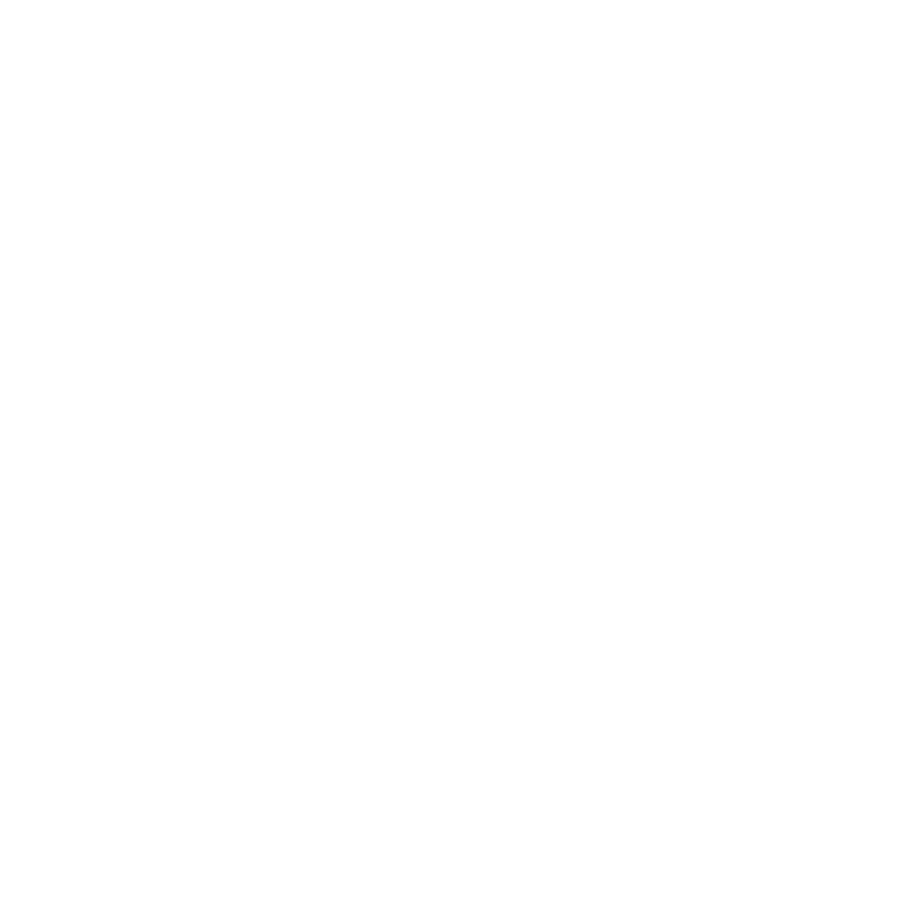

In [19]:
ntrain = 5
xtr = np.linspace(-5., 5., ntrain)
ftr = runge(xtr)
xtest = np.linspace(-5., 5., 333)

bexp = Basis_Approx(xtr, ftr, psi='monomial')
ftest = bexp.predict(xtest)

bexp.plot_components(xtest, ylims=[-1, 2])

In [20]:
# functions generating N+1 Chebyshev nodes of the 1st and 2nd kind 
# for input N, and interval edges a and b

def chebyshev_nodes1(a, b, n):
    '''
    Generate n Chebyshev nodes of the 1st kind for the interval [a,b]
    '''
    return a + 0.5*(b-a)*(1. + np.cos((2.*np.arange(n+1)[::-1]+1)*np.pi/(2.*(n+1))))

def chebyshev_nodes2(a, b, n):
    '''
    Generate n Chebyshev nodes of the 2nd kind for the interval [a,b]
    '''
    return a + 0.5*(b-a)*(1. + np.cos(np.arange(n+1)[::-1]*np.pi/n))

<IPython.core.display.Javascript object>


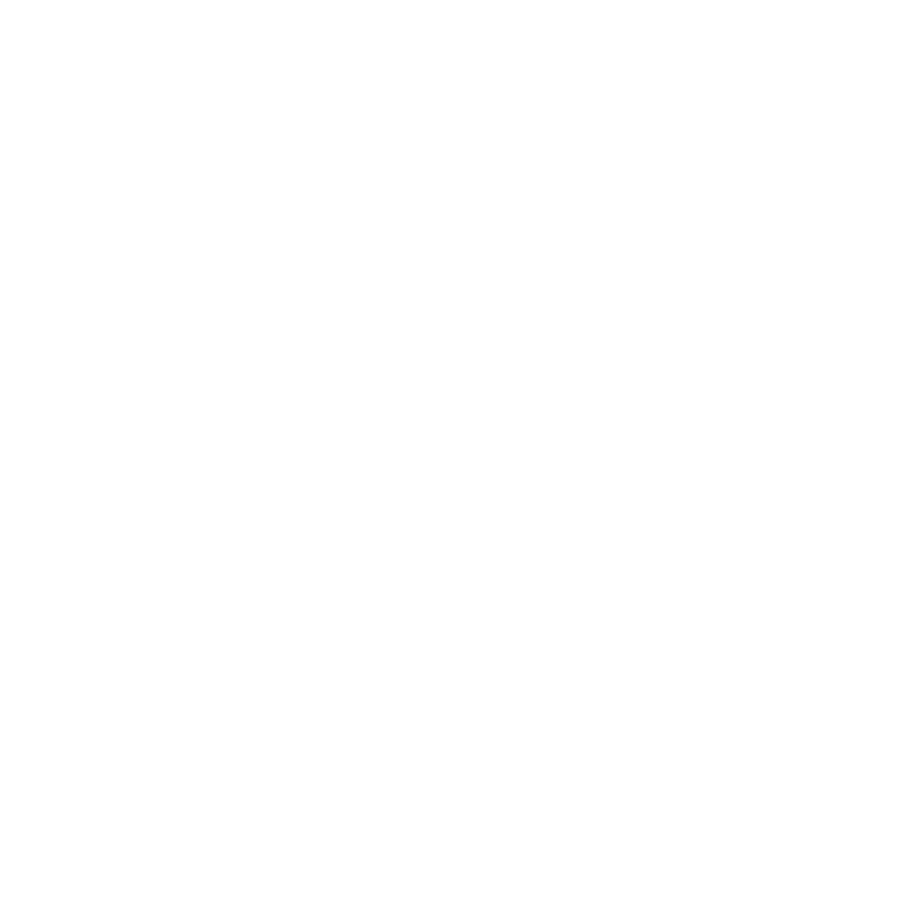

In [21]:
ntrain = 15
xtr = chebyshev_nodes2(-5., 5., ntrain)
ftr = runge(xtr)
xtest = np.linspace(-5., 5., 333)

bexp = Basis_Approx(xtr, ftr, psi='monomial')
ftest = bexp.predict(xtest)

bexp.plot_components(xtest, ylims=[-1, 2])

### <font color='blue'>High-order polynomial interpolation needs to be done using barycentric interpolation formula</font>

not by solving normal equations.

<IPython.core.display.Javascript object>


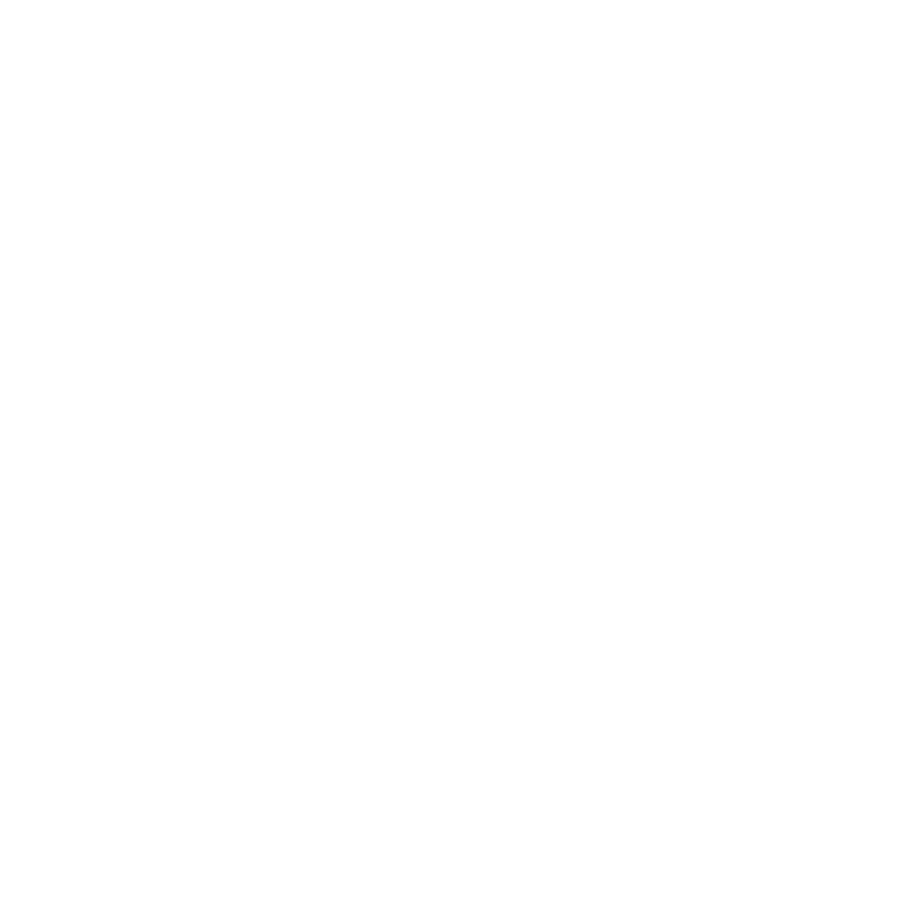

In [22]:
from scipy.interpolate import barycentric_interpolate as bc_int

ftest = bc_int(xtr, ftr, xtest)

plot_line_points(xtest, ftest, xp=xtr, yp=ftr, psize=20,
                 xlabel=r'$x$', ylabel=r'$f(x)$', figsize=3)

<IPython.core.display.Javascript object>


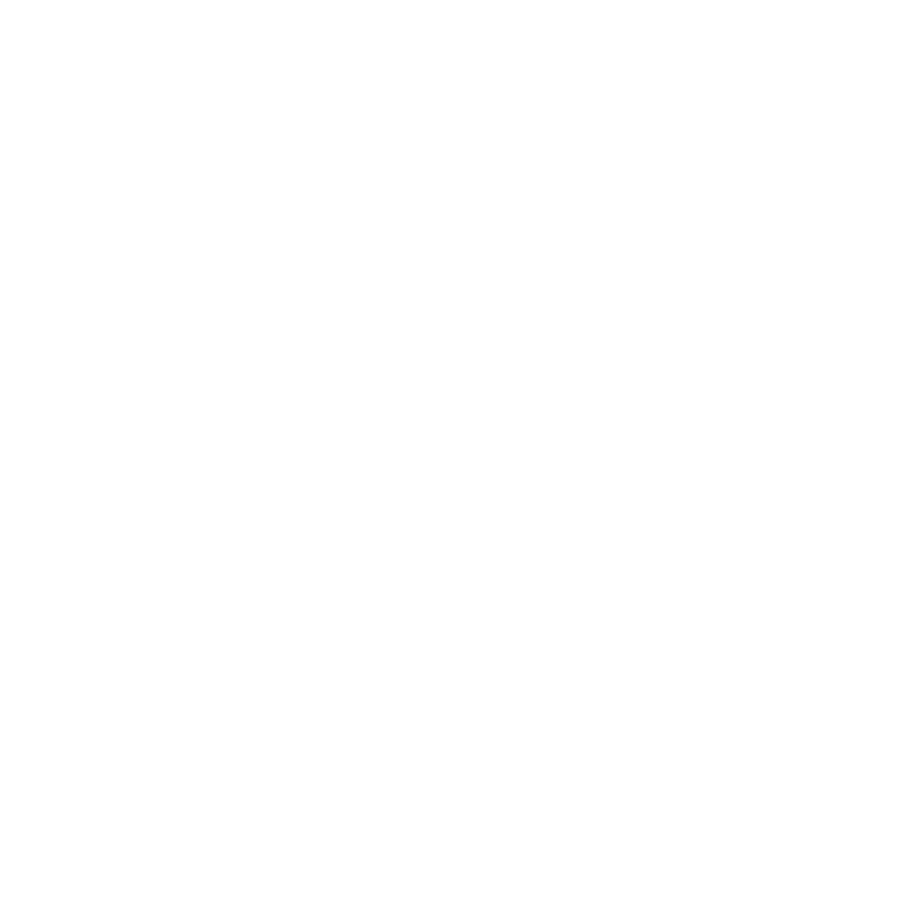

In [23]:
ntrain = 2001
xtr = chebyshev_nodes2(-5., 5., ntrain)
ftr = runge(xtr)

ftest = bc_int(xtr[::2], ftr[::2], xtr[1::2])

plot_line_points(xtr[1::2], ftr[1::2]-ftest, psize=20,
                 xlabel=r'$x$', ylabel=r'$f(x)$', figsize=3)

### <font color='blue'>Splines are not always more accurate than global polynomial approximation</font>

<IPython.core.display.Javascript object>


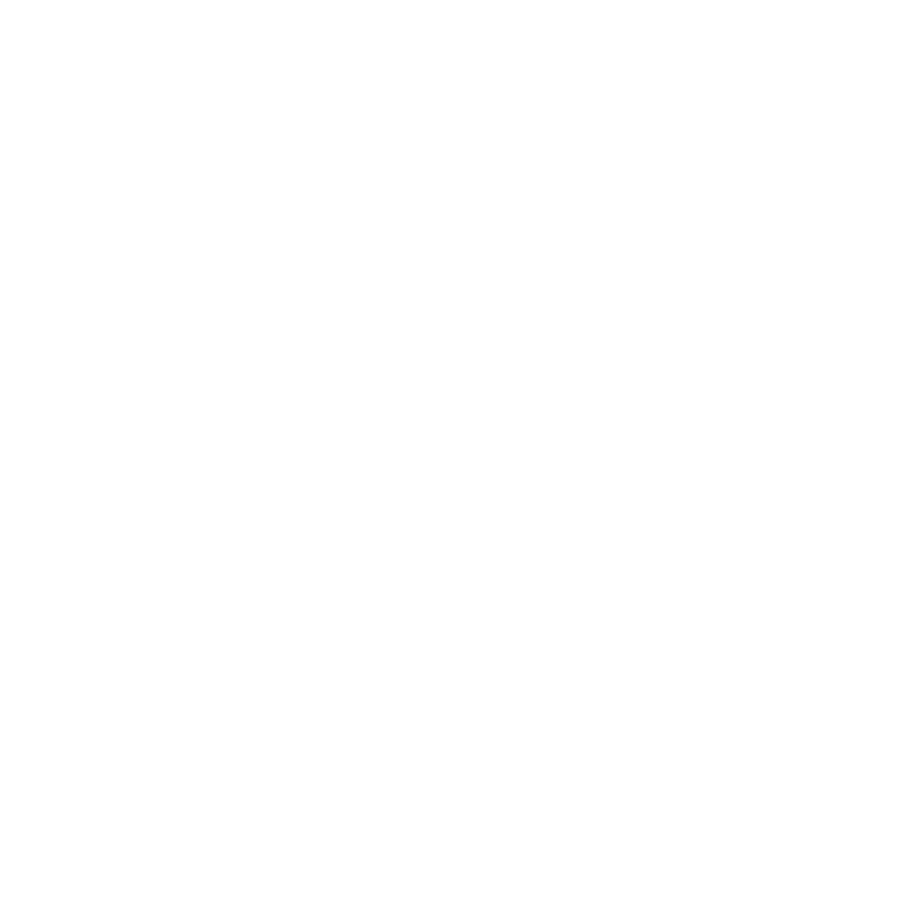

In [24]:
from scipy.interpolate import UnivariateSpline

spl = UnivariateSpline(xtr[::2], ftr[::2], s=0)
ftest = spl(xtr[1::2])

plot_line_points(xtr[1::2], ftr[1::2]-ftest, psize=20,
                 xlabel=r'$x$', ylabel=r'$f(x)$', figsize=3)

### <font color='blue'>but even the barycentric interpolation has its limits: matter power spectrum</font>

In [25]:
k, pk = np.loadtxt('https://astro.uchicago.edu/~andrey/classes/a211/data/test_matterpower_logintk1000.dat', 
                   usecols=(0, 1),  unpack=True)
lk, lpk = np.log10(k), np.log10(pk)


<IPython.core.display.Javascript object>


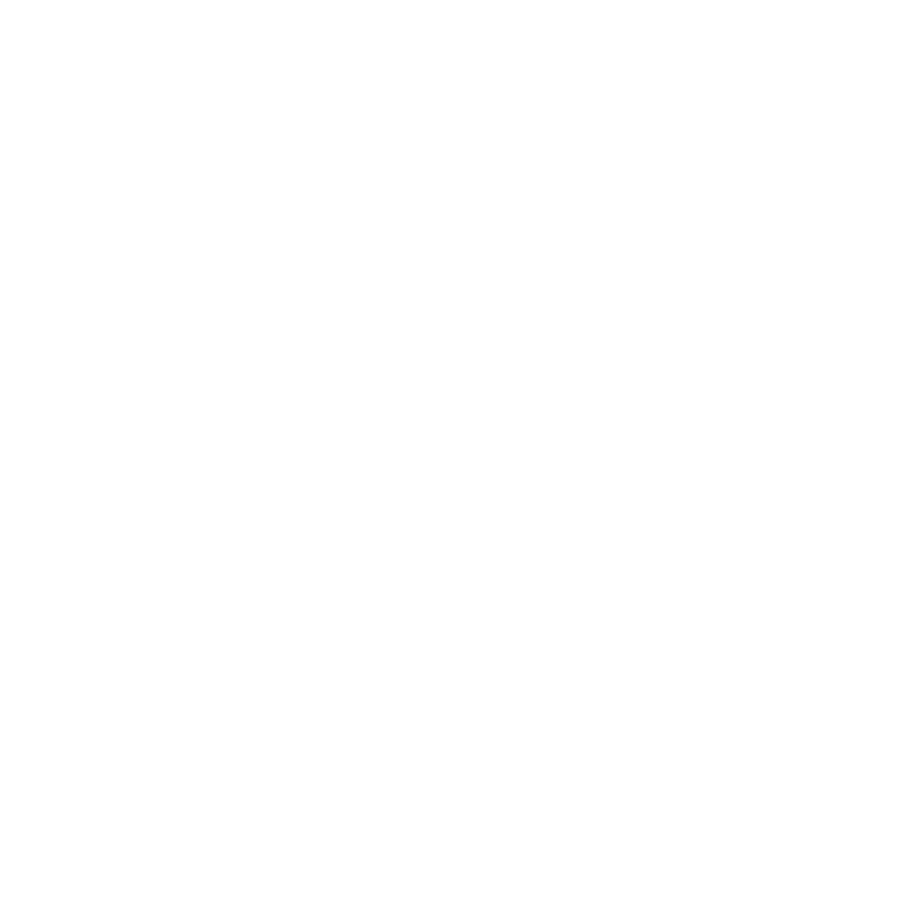

In [26]:
plot_line_points(lk, lpk, xlabel=r'$\log k$', ylabel=r'$\log P(k)$', figsize=3)


The function $P(k)$ is tabulated at 3092 values of $k$ and these are not evenly spaced. Let's try to construct an interpolating polynomial for it, which would have to be of 3091th order. 

In [27]:
lktest = np.linspace(lk.min(), lk.max(), 5000)
lpktest = bc_int(lk, lpk, lktest)


C:\Users\barre\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\barre\anaconda3\Lib\site-packages\scipy\interpolate\_polyint.py:570: RuntimeWarning: overflow encountered in scalar divide
  self.wi[i] = 1.0 / np.prod(dist)
C:\Users\barre\anaconda3\Lib\site-packages\scipy\interpolate\_polyint.py:570: RuntimeWarning: divide by zero encountered in scalar divide
  self.wi[i] = 1.0 / np.prod(dist)
C:\Users\barre\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


<IPython.core.display.Javascript object>


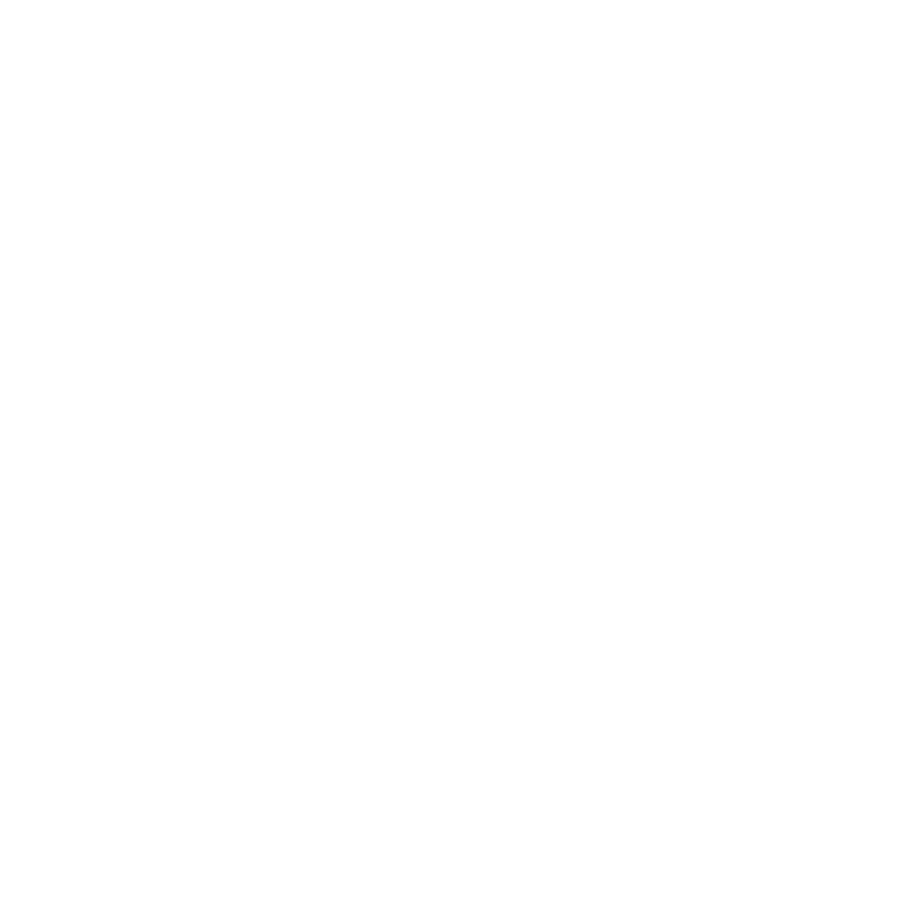

In [28]:
plot_line_points(lktest, lpktest, xp=lk, yp=lpk, xlabel=r'$\log k$', ylabel=r'$\log P(k)$', figsize=3)


<IPython.core.display.Javascript object>


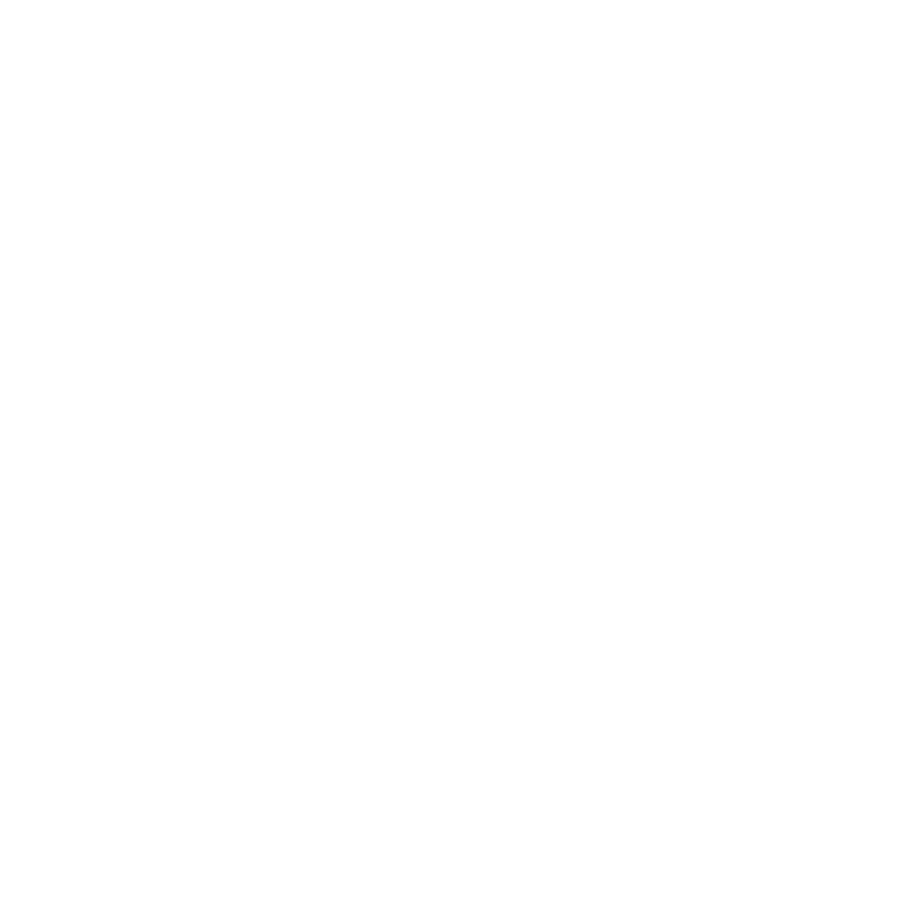

<IPython.core.display.Javascript object>


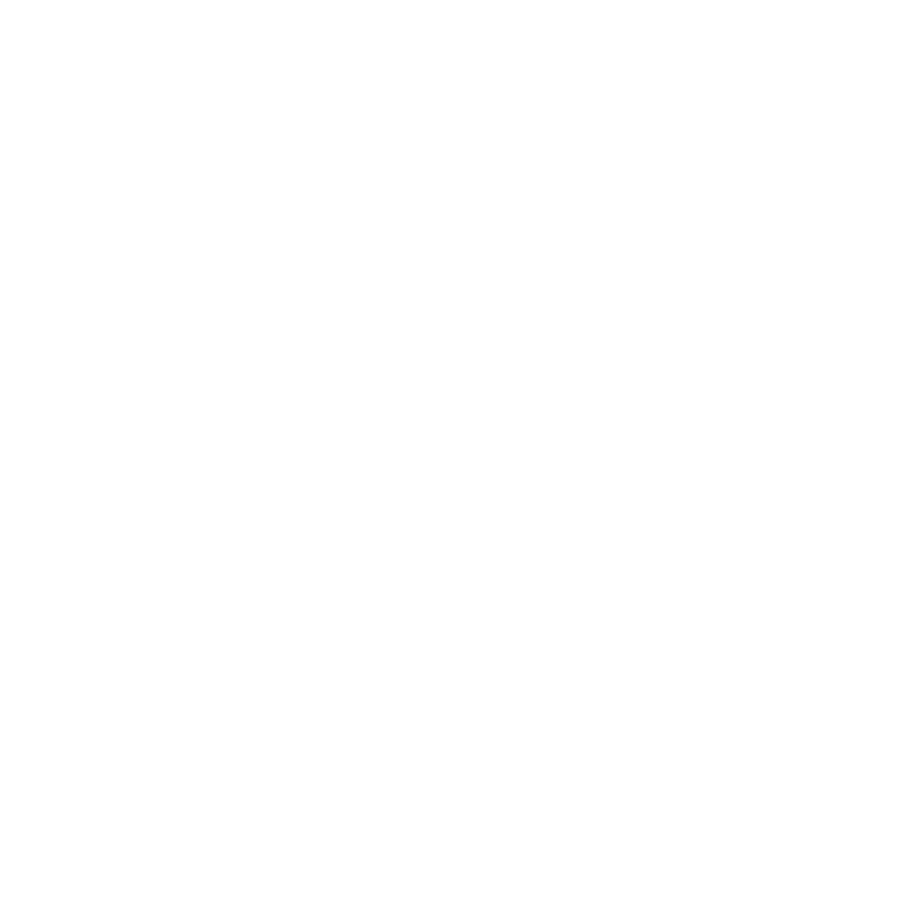

<IPython.core.display.Javascript object>


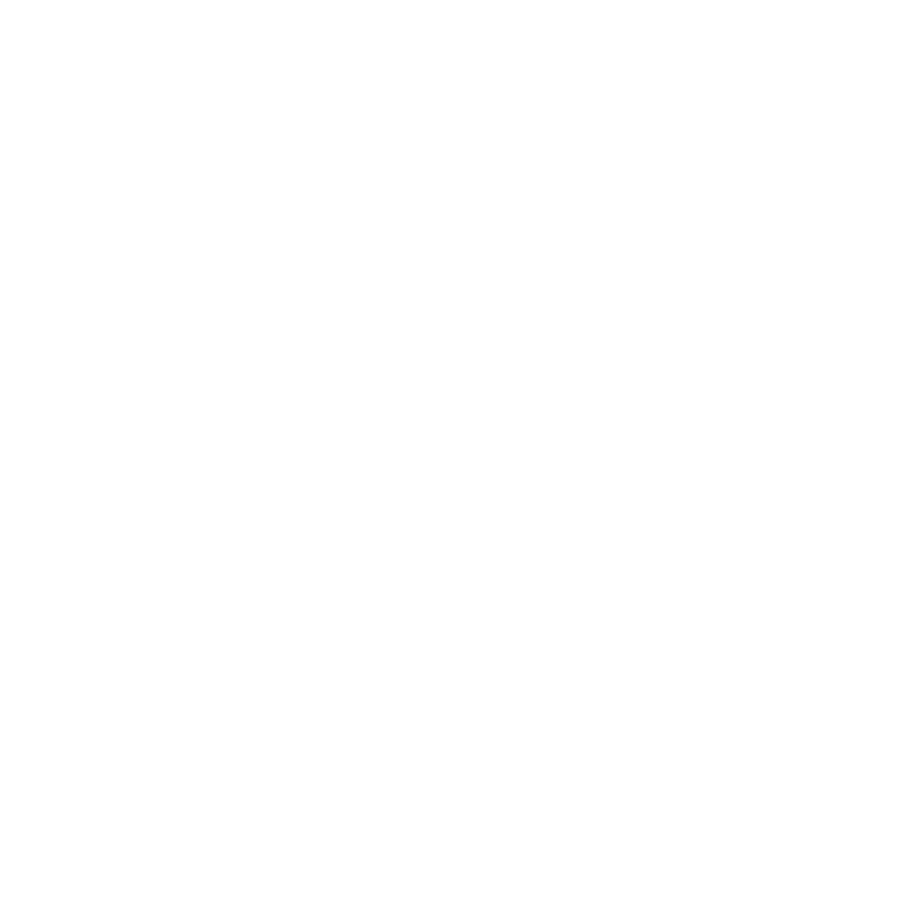

<IPython.core.display.Javascript object>


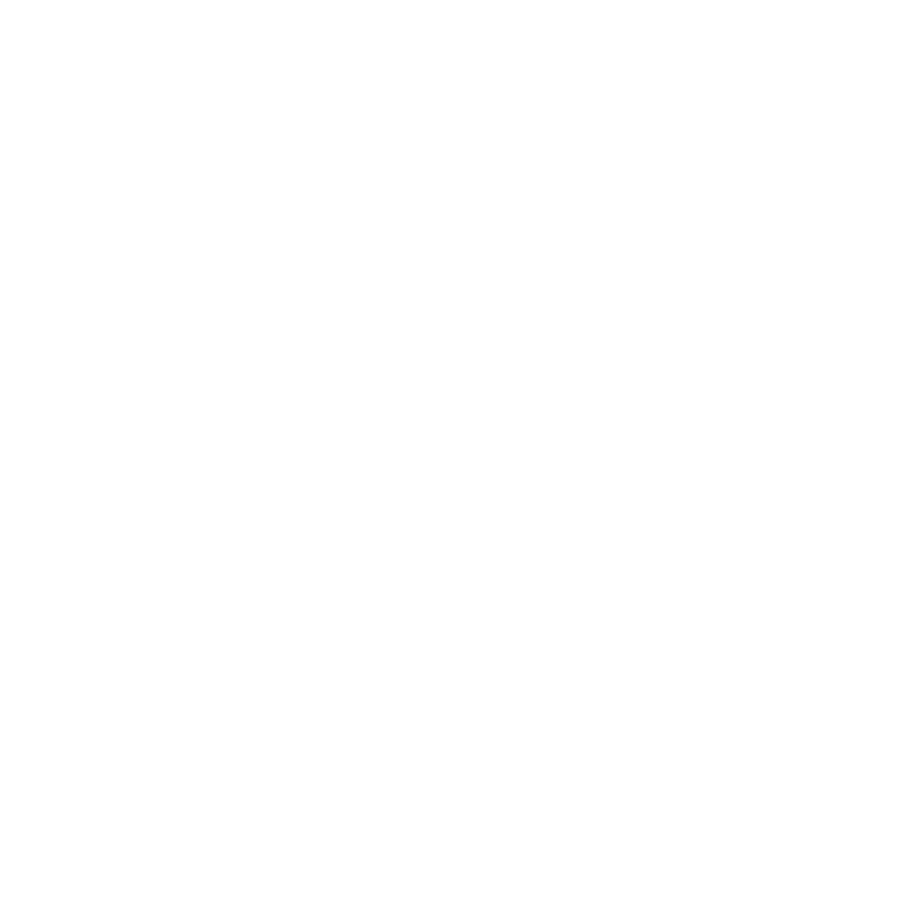

<IPython.core.display.Javascript object>


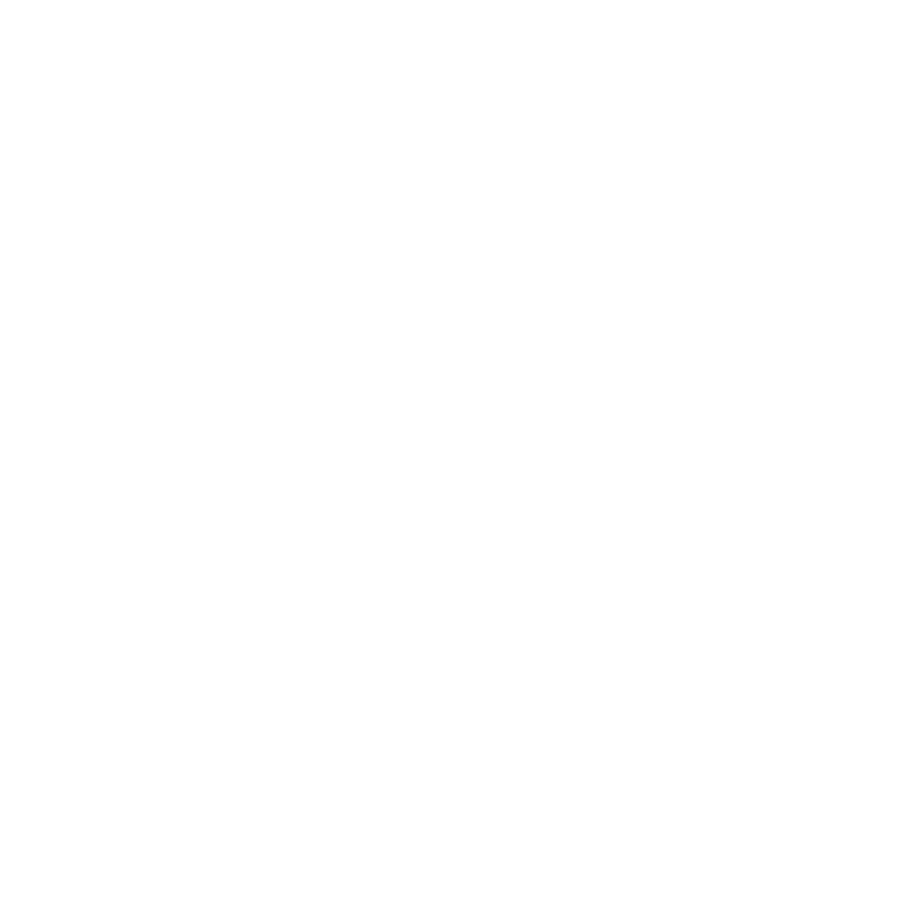

<IPython.core.display.Javascript object>


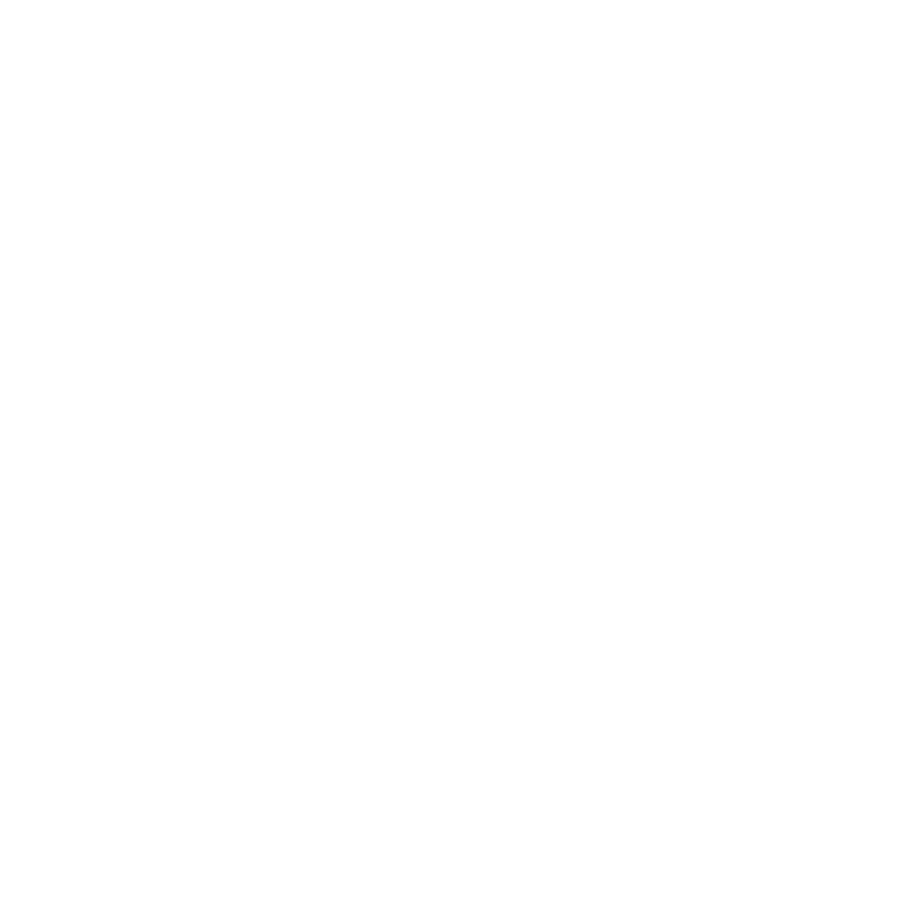

<IPython.core.display.Javascript object>


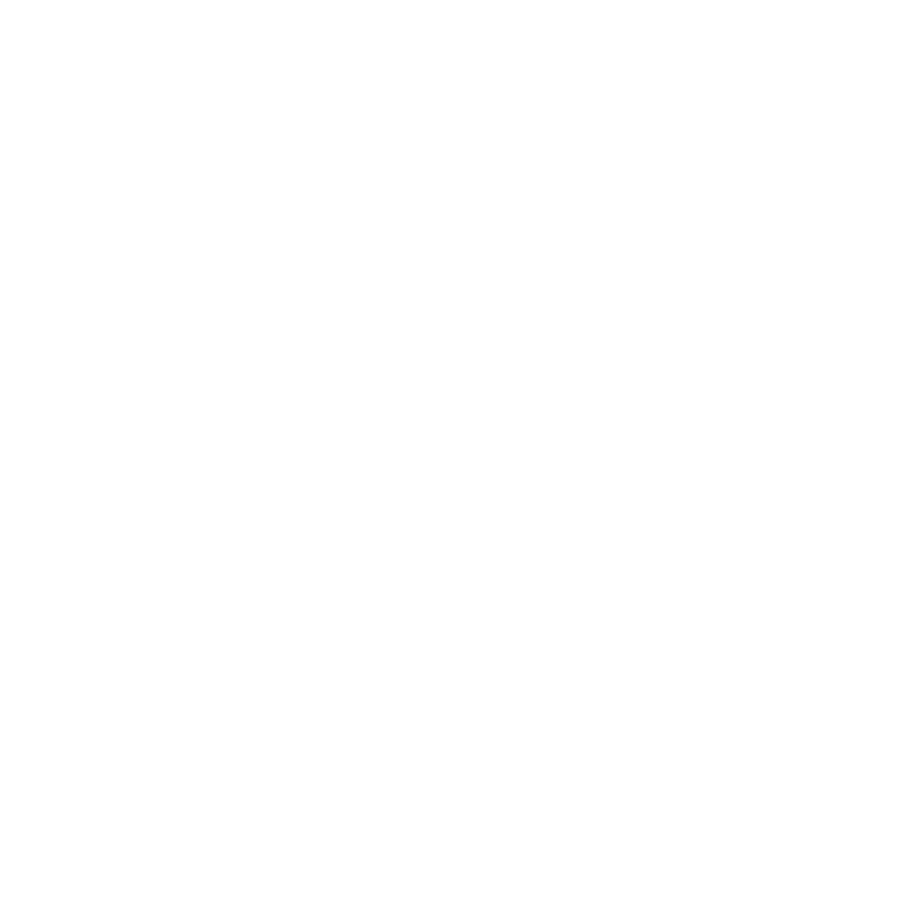

<IPython.core.display.Javascript object>


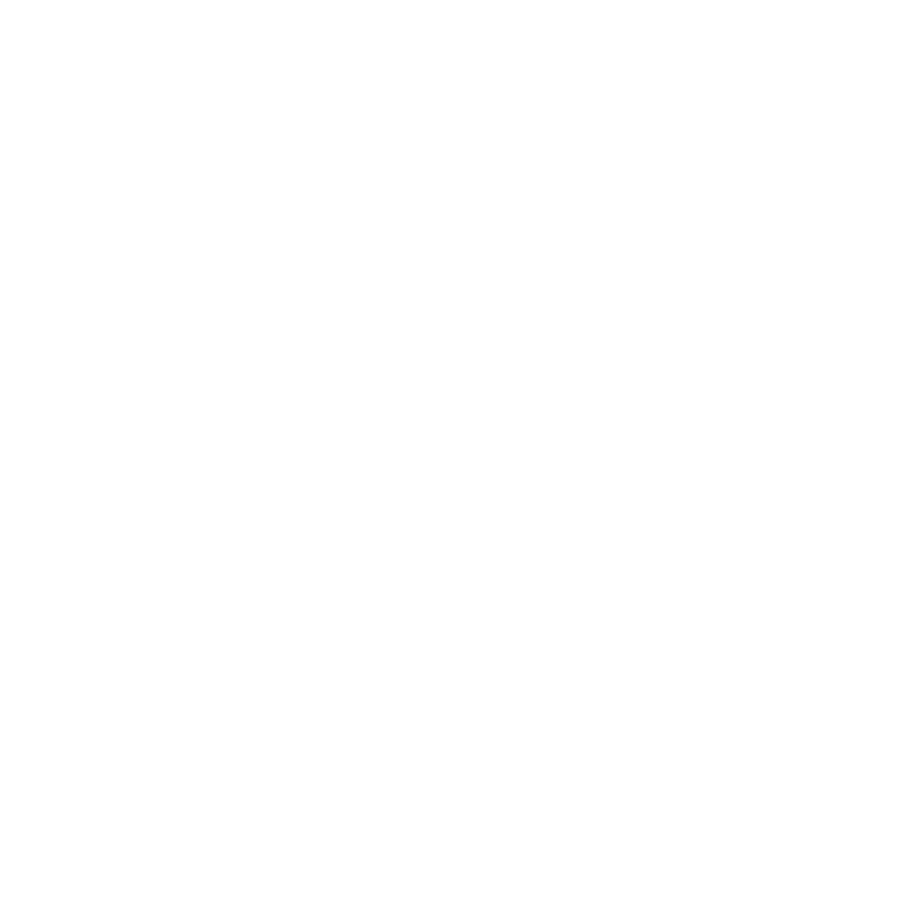

<IPython.core.display.Javascript object>


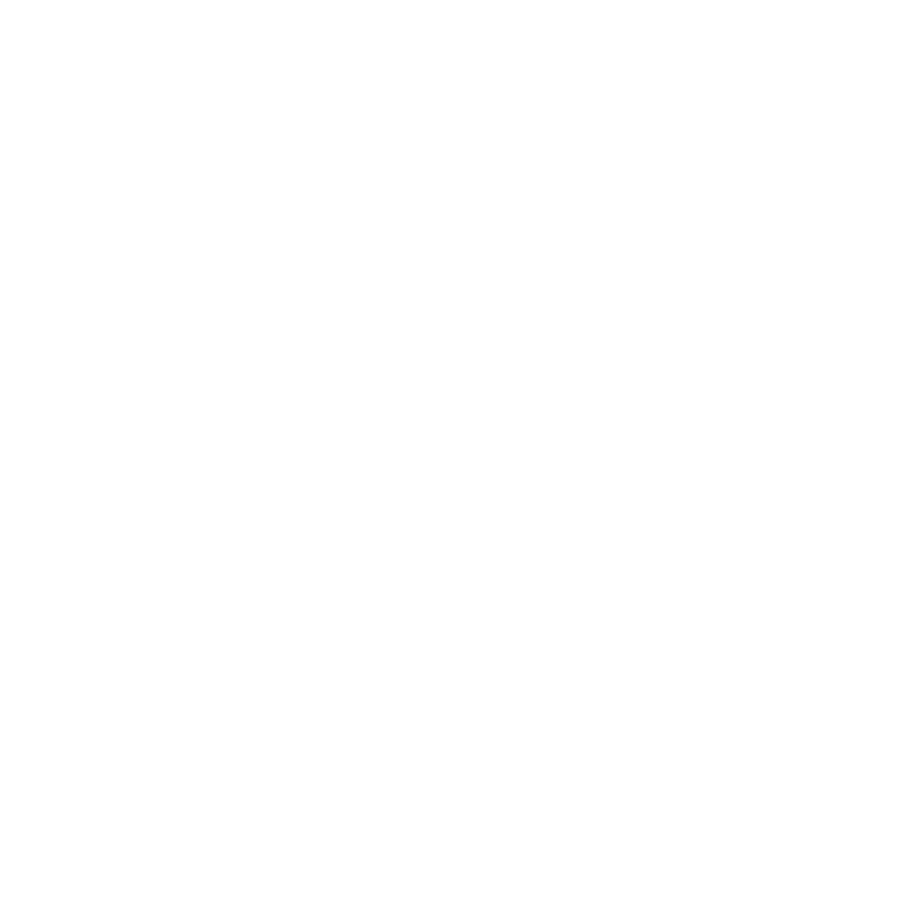

<IPython.core.display.Javascript object>


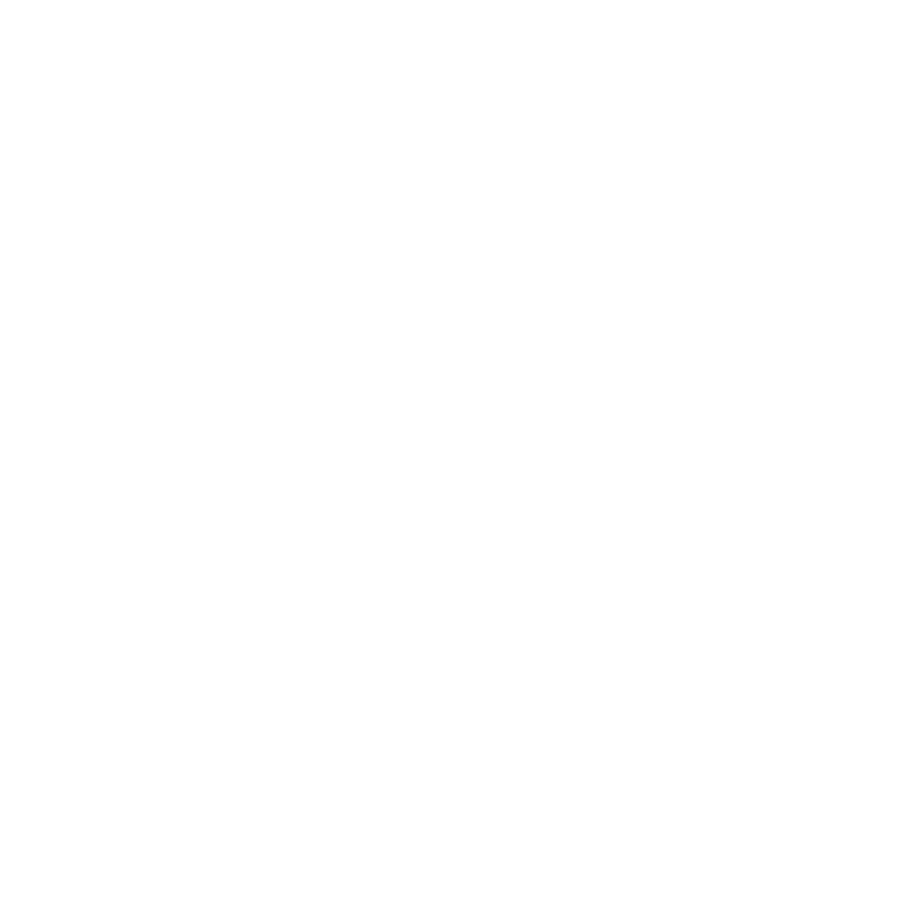

<IPython.core.display.Javascript object>


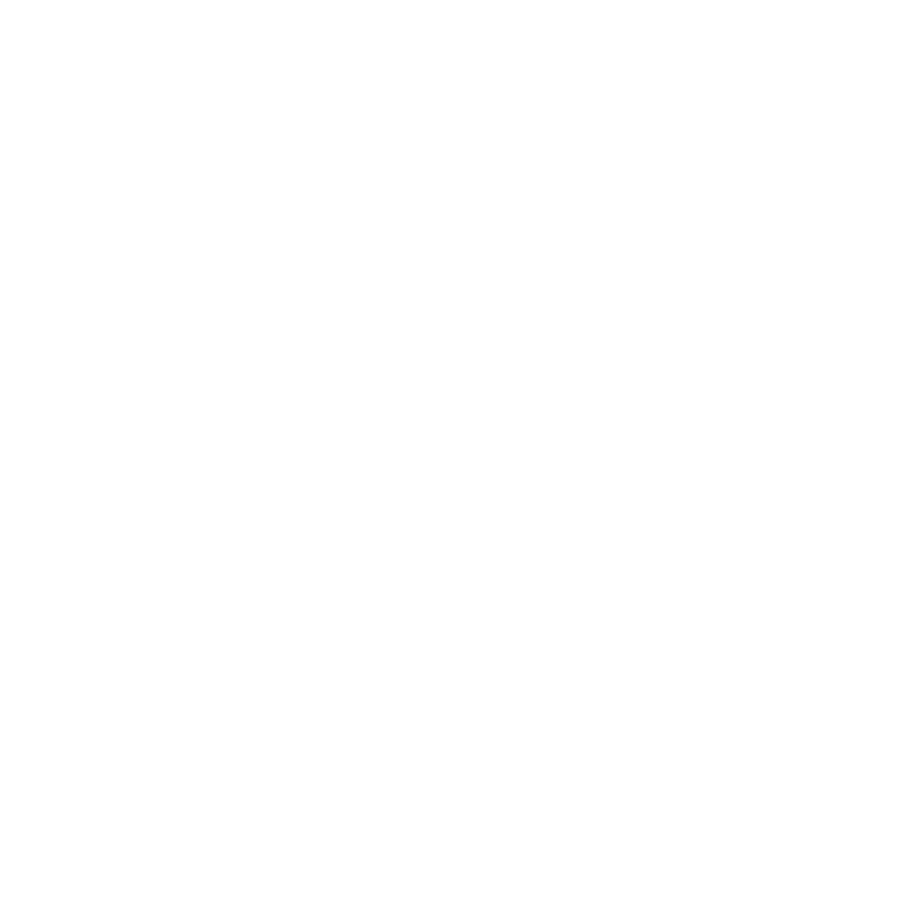

<IPython.core.display.Javascript object>


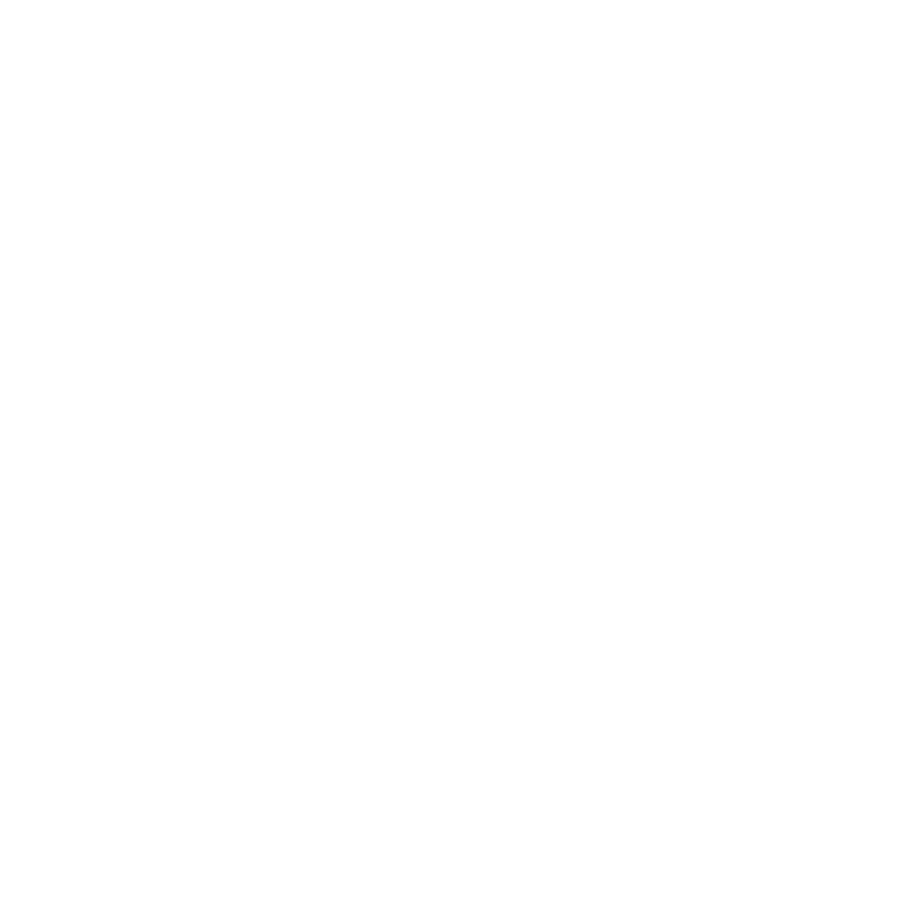

<IPython.core.display.Javascript object>


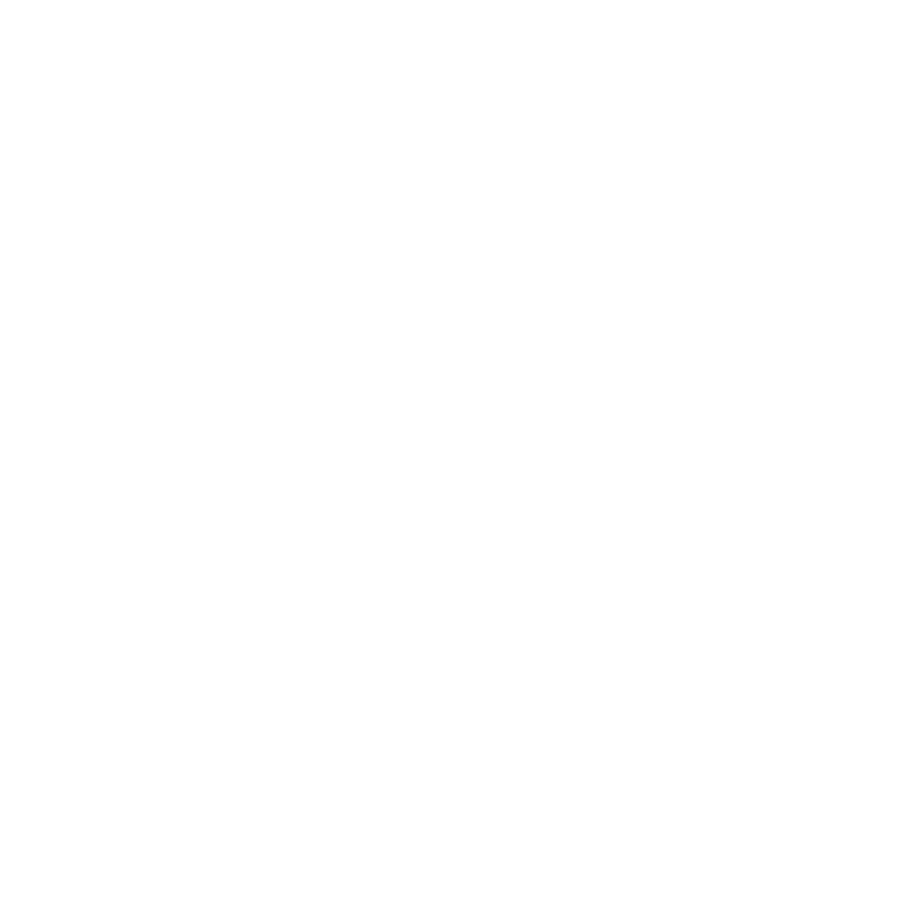

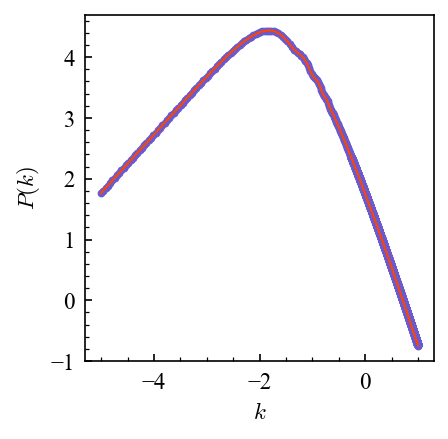

In [29]:
%matplotlib inline
spl = UnivariateSpline(lk, lpk, s=0.)
lkt = np.linspace(lk.min(), lk.max(), 20000)
plot_line_points(lkt, spl(lkt), xp=lk, yp=lpk, psize=30, xlabel=r'$k$', figsize=3, ylabel=r'$P(k)$', col='orangered')


### <font color='blue'>Cubic Splines</font>

Spline approximation of a function can be presented as an expansion using a series of orthogonal $B$-spline functions (see below). However, it is more intuitive to first consider spline approximation as follows. 
    
For a set of $N+1$ points $\{x_i\}$ and corresponding tabulated function values $\{f_i\}$, we define splines for each of $N$ intervals $i$, $[x_i,x_{i+1}]$, as a third order polynomial:

$$
s_i(x) = a_i + b_i(x-x_i) + c_i(x-x_i)^2 + d_i(x-x_i)^3.
$$

$$f(x)\approx \sum\limits_{i=0}^{N} s_i(x)$$


with the following constraints: 

* $s_i(x_i) = f_i,$ - $N$ constraints

* $s_i(x_{i+1})=f_{i+1}$, another $N$ constraints  

* $s^{\prime}_i(x_{i+1})=s^\prime_{i+1}(x_{i+1}),$ additional $N-1$ constraints

* $s^{\prime\prime}_i(x_{i+1})=s^{\prime\prime}_{i+1}(x_{i+1}),$ $\rightarrow N-1$ constraints. 

We thus have $4N-2$ constraints, but we need to determine $4N$ coefficients for splines in all $N$ intervals. Two additional constraints are chosen for the edge points of the interval within which we approximate the function, $x_0$ and $x_N$. Different choices of such edge constraints result in spline interpolations of different type. 


### <font color='blue'>Why do we need to approximate functions? </font>

* Accurate approximation can be used to compute function inverse.

In [30]:
zsn, msn, emsn, x1, ex1, csn, ecsn = np.loadtxt('https://astro.uchicago.edu/~andrey/classes/a211/data/jla_lcparams.txt', 
                                               usecols=(1, 4, 5, 6, 7, 8, 9), unpack=True)

zsn = np.unique(zsn)
print("read sample of %d supernovae..."%(np.size(zsn)))

read sample of 732 supernovae...


In [31]:
# construct empirical cdf for the sample
zsort = np.sort(zsn)
cdf = np.arange(1, zsn.size+1) / (zsn.size) # construct cumulative distribution function


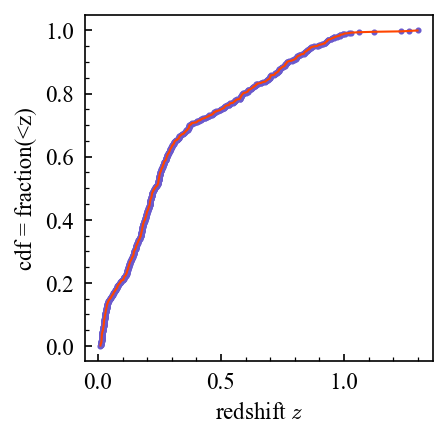

In [32]:
%matplotlib inline
zspl = UnivariateSpline(cdf, zsort, s=0.0)

plot_line_points(xp=zsort, yp=cdf,  x=zspl(cdf), y = cdf, col='orangered', psize=15, 
                 xlabel='redshift $z$', ylabel='cdf = fraction(<z)', figsize=3)

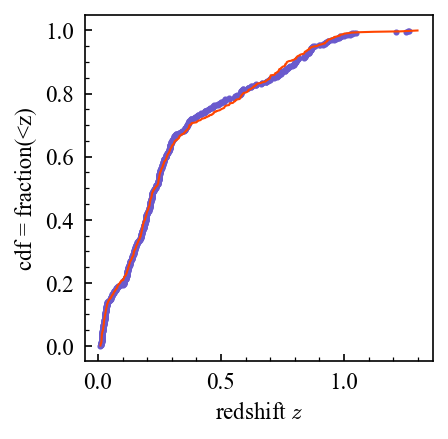

In [33]:
y = np.random.uniform(size=740)
zr = zspl(y)
zsr = np.sort(zr)
cdfr = np.arange(1, zsr.size+1) / (zsr.size+1)

plot_line_points(xp=zsr, yp=cdfr, x=zsort, y=cdf, col='orangered', psize=15,
                 xlabel='redshift $z$', ylabel='cdf = fraction(<z)', figsize=3)

### <font color='blue'>Generate mock magnitudes for SN Ia </font>

In [34]:
# construct empirical cdf for the sample
msort = np.sort(msn)
cdf = np.arange(1, msn.size+1) / (msn.size) # construct cumulative distribution function
mspl = UnivariateSpline(cdf, msort, s=0.0)
y = np.random.uniform(size=740)
mr = mspl(y)
msr = np.sort(mr) + np.random.normal(scale=0.1, size=740)


### <font color='blue'>We generated a mock sample of supernovae type Ia </font>

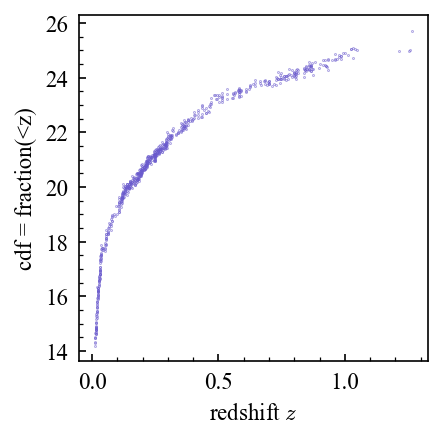

In [35]:
plot_line_points(xp=zsr, yp=msr, col='orangered', psize=0.2,
                 xlabel='redshift $z$', ylabel='cdf = fraction(<z)', figsize=3)

### <font color='blue'>Why do we need to approximate functions? </font>

* To speed up calculation of a function.

In [36]:
from astropy.cosmology import LambdaCDM
import astropy.units as u

def d_l_astropy(z, H0, Om0, OmL):
    cosmo = LambdaCDM(H0=H0, Om0=Om0, Ode0=OmL)
    return cosmo.luminosity_distance(z=z) / u.Mpc

In [37]:
ntrain = 15 # number of the training points
om0min, om0max = 0., 1.

# evenly spaced training points
om0train = np.linspace(om0min, om0max, ntrain)
dltrain = np.zeros_like(om0train)
z = 2.; H0 = 70.
for i, om in enumerate(om0train): 
    dltrain[i] = d_l_astropy(z, H0, om, 1.-om)

# construct object - the instance of the cubic spline class: s=0 corresponds to interpolation, s>0 does spline regression
dl_spl = UnivariateSpline(om0train, dltrain, s=0)

In [38]:
from time import time

nrand = 10000
om0 = np.random.uniform(0., 1., size=nrand)

z = 2.; H0 = 70.
t0 = time()
d_apy = np.zeros_like(om0)
for i, om in enumerate(om0): 
    d_apy[i] = d_l_astropy(z, H0, om, 1.-om)
       
print(f'Calculation using AstroPy d_L finished in {time()-t0:.2f} sec')

t0 = time()
dspl = np.zeros_like(om0)
for i, om in enumerate(om0): 
    dspl[i] = dl_spl(om)

print(f'Calculation using spline d_L finished in {time()-t0:.2f} sec')

ferr = np.abs(dspl/d_apy-1)
ferr.max()

Calculation using AstroPy d_L finished in 21.41 sec
Calculation using spline d_L finished in 0.11 sec


0.007229902326974402

In [39]:
nrand = 10000
om0 = np.random.uniform(0., 1., size=nrand)

dspl = dl_spl(om0)
ferr = np.abs(dspl/d_apy-1)
ferr.max()

1.3395760670267949

### <font color='blue'>Why do we need to approximate functions? </font>

* To have easily calculable approximation for the integral or derivatives of a function. 

In [40]:

x = np.linspace(0., 2*np.pi, 200)
y = np.sin(x)

spl = UnivariateSpline(x, y, s=0)
dspl = spl.derivative(4) # spline derivative object

plot_line_points(x=x, y=y, xlabel='$x$', ylabel='$\sin(x)$', figsize=3)

ValueError: Order of derivative (n = 4) must be <= order of spline (k = 3)

In [ ]:
xp = np.linspace(0., 2*np.pi, 20)
yp = dspl(xp)
plot_line_points(xp=xp, yp=yp, x=x, y=-np.cos(x), psize=30, xlabel='$x$', ylabel=r'$\sin^\prime(x)$', figsize=3)

### <font color='blue'>A more realistic example</font>

In [ ]:
plot_line_points(x=lk, y=lpk, xlabel='wavenumber $k$', ylabel='$P(k)$', figsize=3)

In [ ]:
lpk_spl = UnivariateSpline(lk, lpk, s=0.)

dlpkdlk_spk = lpk_spl.derivative()
plot_line_points(x=lk, y=dlpkdlk_spk(lk), 
                 xlabel='wavenumber $k$', ylabel='$d\ln P(k)/d\ln k$', figsize=3)

### <font color='blue'>Polynomial regression </font>

In [ ]:
def ftr_func(x, scale=0.5): 
    return 1.5*x + np.sin(x) + np.random.normal(scale=1, size=xtr.size)

In [ ]:
xtr = np.linspace(0, 6, 30)
xt = np.linspace(0, 6, 200)
ftr = ftr_func(xtr) 

In [ ]:
# make sure that order is smaller than the size of the training sample
porder = 5 
# compute polynomial coefficients by solving system of normal equations
polyfit = np.polyfit(xtr, ftr, porder)
# initialize 1d polynomial class with these coefficients
pfit = np.poly1d(polyfit) 
# compute approximation at test values
ftest = pfit(xt)

plot_line_points(xt, ftest, xp=xtr, yp=ftr, points=True, psize=40, 
                 xlabel=r'$x$', ylabel=r'$f(x)$', figsize=3)

### <font color='blue'>Spline regression </font>

<tt>UnivariateSpline</tt> allows construction of the spline that is not interpolating data, but approximating it using the least squares regression. 

For <tt>s>0</tt> <tt>UnivariateSpline</tt> constructs spline that satisfies condition for the $N+1$ training points $x_i$:

$$\sum\limits_{i=0}^N [f_i-{\rm spline}(x_i)]^2 \leq s$$

by solving the system of for the spline coefficients subject to condition above and smoothness constraints. 


In [ ]:
from scipy.interpolate import UnivariateSpline

spl = UnivariateSpline(xtr, ftr, s=0)

ftest = spl(xt)

plot_line_points(xt, ftest, xp=xtr, yp=ftr, points=True, psize=40, 
                 xlabel=r'$x$', ylabel=r'$f(x)$', figsize=3)